# 🐾 EDA - PetFinder.my Adoption Prediction

**Objetivo:** Analizar los datos de mascotas para entender qué factores influyen en la velocidad de adopción.

**Variable objetivo:** `AdoptionSpeed` (0 = mismo día, 1 = 1-7 días, 2 = 8-30 días, 3 = 31-90 días, 4 = no adoptado en 100 días)

## 1. 📦 Importación de librerías y carga de datos

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

# Carga de datos
train = pd.read_csv('train_clean.csv')
test  = pd.read_csv('../data/test.csv')

print(f'Train: {train.shape[0]} filas, {train.shape[1]} columnas')
print(f'Test:  {test.shape[0]} filas, {test.shape[1]} columnas')
train.head()

Train: 14993 filas, 27 columnas
Test:  3972 filas, 23 columnas


,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,has_breed2,has_color2,has_color3
0,2,Nibble,3,299,0,1,1,7,0,1,...,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2,0,1,0
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0,0,1,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3,0,1,0
3,1,Miko,4,307,0,2,1,2,0,2,...,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2,0,1,0
4,1,Hunter,1,307,0,1,1,0,0,2,...,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2,0,0,0


## 2. 🗺️ Diccionario de variables

| Columna | Descripción | Valores |
|---|---|---|
| Type | Tipo de mascota | 1=Perro, 2=Gato |
| Age | Edad en meses | - |
| Breed1/2 | Raza principal/secundaria | ID numérico |
| Gender | Género | 1=Macho, 2=Hembra, 3=Mixto |
| Color1/2/3 | Colores | ID numérico |
| MaturitySize | Tamaño adulto | 1=Pequeño, 2=Medio, 3=Grande, 4=Extra Grande |
| FurLength | Largo del pelo | 1=Corto, 2=Medio, 3=Largo |
| Vaccinated | Vacunado | 1=Sí, 2=No, 3=No sabe |
| Dewormed | Desparasitado | 1=Sí, 2=No, 3=No sabe |
| Sterilized | Esterilizado | 1=Sí, 2=No, 3=No sabe |
| Health | Estado de salud | 1=Sano, 2=Lesión menor, 3=Lesión grave |
| Quantity | Número de mascotas en el anuncio | - |
| Fee | Tarifa de adopción | 0=Gratis |
| PhotoAmt | Número de fotos | - |
| VideoAmt | Número de vídeos | - |
| **AdoptionSpeed** | **Variable objetivo** | **0-4** |

## 3. 🔍 Exploración inicial

In [27]:
print('=== TIPOS DE DATOS ===')
print(train.dtypes)
print('\n=== ESTADÍSTICAS DESCRIPTIVAS ===')
train.describe()

=== TIPOS DE DATOS ===
Type               int64
Name                 str
Age                int64
Breed1             int64
Breed2             int64
Gender             int64
Color1             int64
Color2             int64
Color3             int64
MaturitySize       int64
FurLength          int64
Vaccinated         int64
Dewormed           int64
Sterilized         int64
Health             int64
Quantity           int64
Fee                int64
State              int64
RescuerID            str
VideoAmt           int64
Description          str
PetID                str
PhotoAmt         float64
AdoptionSpeed      int64
has_breed2         int64
has_color2         int64
has_color3         int64
dtype: object

=== ESTADÍSTICAS DESCRIPTIVAS ===


,Type,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,...,Health,Quantity,Fee,State,VideoAmt,PhotoAmt,AdoptionSpeed,has_breed2,has_color2,has_color3
count,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,...,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000,14993.000000
mean,1.457614,10.421930,265.272594,74.009738,1.776162,2.234176,3.222837,1.882012,1.862002,1.467485,...,1.036617,1.561195,20.473821,41346.028347,0.056760,3.851064,2.516441,0.282198,0.701794,0.292737
std,0.498217,17.741828,60.056818,123.011575,0.681592,1.745225,2.742562,2.984086,0.547959,0.599070,...,0.199535,1.343045,68.474185,32.444153,0.346185,3.265167,1.177265,0.450084,0.457486,0.455034
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,1.000000,0.000000,41324.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2.000000,265.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,1.000000,...,1.000000,1.000000,0.000000,41326.000000,0.000000,2.000000,2.000000,0.000000,0.000000,0.000000
50%,1.000000,3.000000,266.000000,0.000000,2.000000,2.000000,2.000000,0.000000,2.000000,1.000000,...,1.000000,1.000000,0.000000,41326.000000,0.000000,3.000000,2.000000,0.000000,1.000000,0.000000
75%,2.000000,12.000000,307.000000,179.000000,2.000000,3.000000,6.000000,5.000000,2.000000,2.000000,...,1.000000,1.000000,0.000000,41401.000000,0.000000,5.000000,4.000000,1.000000,1.000000,1.000000
max,2.000000,144.000000,307.000000,307.000000,3.000000,7.000000,7.000000,7.000000,4.000000,3.000000,...,3.000000,10.000000,500.000000,41415.000000,8.000000,20.000000,4.000000,1.000000,1.000000,1.000000


=== VALORES NULOS ===
             Nulos  Porcentaje (%)
Name          1265            8.44
Description     13            0.09


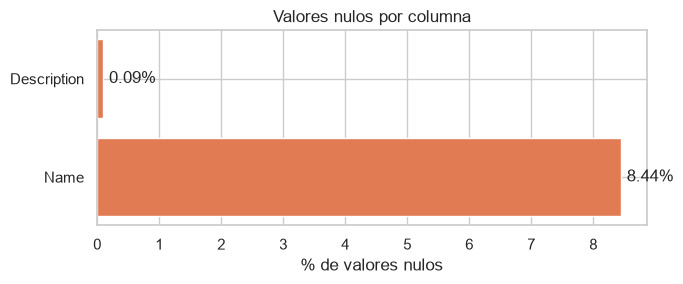


✅ Conclusión: muy pocos nulos. Name (~8.4%) y Description (~0.09%) son aceptables.


In [28]:
# Valores nulos
nulos = train.isnull().sum()
nulos_pct = (nulos / len(train) * 100).round(2)
nulos_df = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
nulos_df = nulos_df[nulos_df['Nulos'] > 0]

print('=== VALORES NULOS ===')
print(nulos_df)

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(nulos_df.index, nulos_df['Porcentaje (%)'], color='#e07b54')
ax.set_xlabel('% de valores nulos')
ax.set_title('Valores nulos por columna')
for i, v in enumerate(nulos_df['Porcentaje (%)']):
    ax.text(v + 0.1, i, f'{v}%', va='center')
plt.tight_layout()
plt.show()

print('\n✅ Conclusión: muy pocos nulos. Name (~8.4%) y Description (~0.09%) son aceptables.')

## 4. 🎯 Variable objetivo: AdoptionSpeed

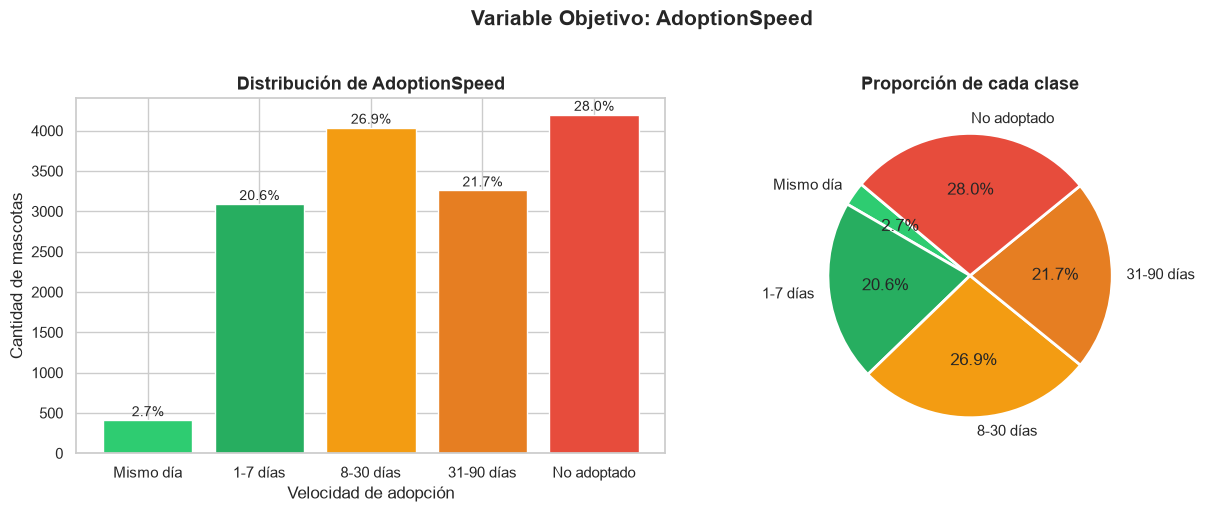


📊 Observaciones:
  - El 28.0% de mascotas NO fueron adoptadas en 100 días → clase desafiante
  - El 2.7% se adoptan el mismo día → clase muy minoritaria
  - Dataset moderadamente desbalanceado → considerar técnicas de balanceo (SMOTE, class_weight)


In [29]:
labels_speed = {
    0: 'Mismo día',
    1: '1-7 días',
    2: '8-30 días',
    3: '31-90 días',
    4: 'No adoptado'
}

counts = train['AdoptionSpeed'].value_counts().sort_index()
pcts   = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras
colors = ['#2ecc71','#27ae60','#f39c12','#e67e22','#e74c3c']
bars = axes[0].bar([labels_speed[i] for i in counts.index], counts.values, color=colors, edgecolor='white')
axes[0].set_title('Distribución de AdoptionSpeed', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de mascotas')
axes[0].set_xlabel('Velocidad de adopción')
for bar, pct in zip(bars, pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{pct:.1f}%', ha='center', fontsize=10)

# Pie
axes[1].pie(counts.values, labels=[labels_speed[i] for i in counts.index],
            colors=colors, autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[1].set_title('Proporción de cada clase', fontsize=13, fontweight='bold')

plt.suptitle('Variable Objetivo: AdoptionSpeed', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n📊 Observaciones:')
print(f'  - El {pcts[4]:.1f}% de mascotas NO fueron adoptadas en 100 días → clase desafiante')
print(f'  - El {pcts[0]:.1f}% se adoptan el mismo día → clase muy minoritaria')
print('  - Dataset moderadamente desbalanceado → considerar técnicas de balanceo (SMOTE, class_weight)')

## 5. 🐶🐱 Tipo de mascota (Perro vs Gato)

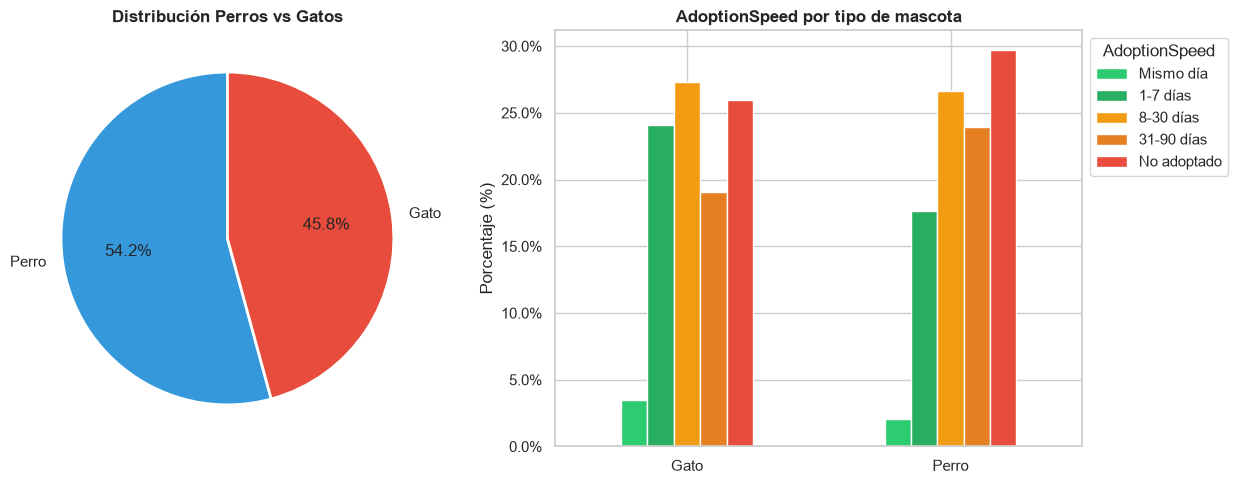

  AdoptionSpeed medio (Perro): 2.62
  AdoptionSpeed medio (Gato): 2.40


In [30]:
train['Type_label'] = train['Type'].map({1: 'Perro', 2: 'Gato'})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribución general
type_counts = train['Type_label'].value_counts()
axes[0].pie(type_counts.values, labels=type_counts.index,
            colors=['#3498db','#e74c3c'], autopct='%1.1f%%',
            wedgeprops={'edgecolor':'white','linewidth':2}, startangle=90)
axes[0].set_title('Distribución Perros vs Gatos', fontweight='bold')

# AdoptionSpeed por tipo
ct = train.groupby(['Type_label','AdoptionSpeed']).size().unstack()
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.rename(columns=labels_speed).plot(kind='bar', ax=axes[1],
    color=colors, edgecolor='white')
axes[1].set_title('AdoptionSpeed por tipo de mascota', fontweight='bold')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='AdoptionSpeed', labels=labels_speed.values(), bbox_to_anchor=(1,1))
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

# Estadísticas
for tipo in ['Perro','Gato']:
    media = train[train['Type_label']==tipo]['AdoptionSpeed'].mean()
    print(f'  AdoptionSpeed medio ({tipo}): {media:.2f}')

## 6. 📅 Edad de las mascotas

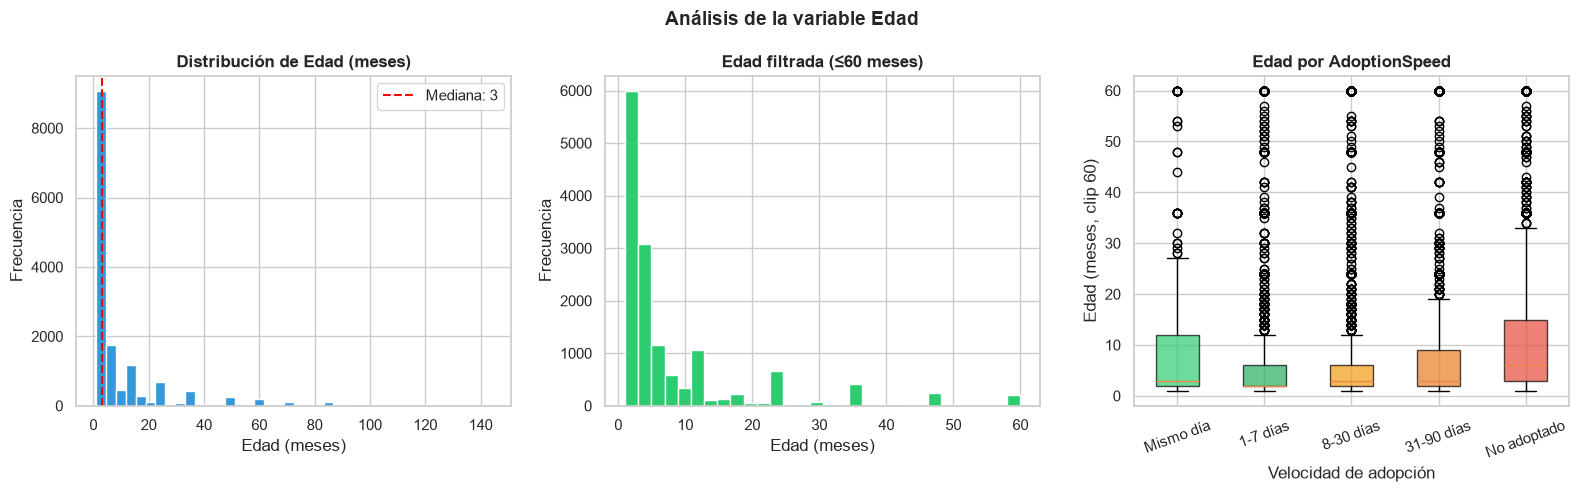

Edad mínima: 1 meses | Máxima: 144 meses | Mediana: 3.0 meses
El 53.0% de las mascotas tienen 3 meses o menos (cachorros/gatitos)


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histograma general
axes[0].hist(train['Age'], bins=40, color='#3498db', edgecolor='white')
axes[0].set_title('Distribución de Edad (meses)', fontweight='bold')
axes[0].set_xlabel('Edad (meses)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(train['Age'].median(), color='red', linestyle='--', label=f'Mediana: {train["Age"].median():.0f}')
axes[0].legend()

# Histograma filtrado (sin outliers extremos)
age_filtered = train[train['Age'] <= 60]
axes[1].hist(age_filtered['Age'], bins=30, color='#2ecc71', edgecolor='white')
axes[1].set_title('Edad filtrada (≤60 meses)', fontweight='bold')
axes[1].set_xlabel('Edad (meses)')
axes[1].set_ylabel('Frecuencia')

# Boxplot por AdoptionSpeed
data_box = [train[train['AdoptionSpeed']==i]['Age'].clip(upper=60) for i in range(5)]
bp = axes[2].boxplot(data_box, tick_labels=[labels_speed[i] for i in range(5)], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title('Edad por AdoptionSpeed', fontweight='bold')
axes[2].set_xlabel('Velocidad de adopción')
axes[2].set_ylabel('Edad (meses, clip 60)')
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle('Análisis de la variable Edad', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Edad mínima: {train["Age"].min()} meses | Máxima: {train["Age"].max()} meses | Mediana: {train["Age"].median()} meses')
print(f'El {(train["Age"] <= 3).sum() / len(train) * 100:.1f}% de las mascotas tienen 3 meses o menos (cachorros/gatitos)')

## 7. 👤 Género

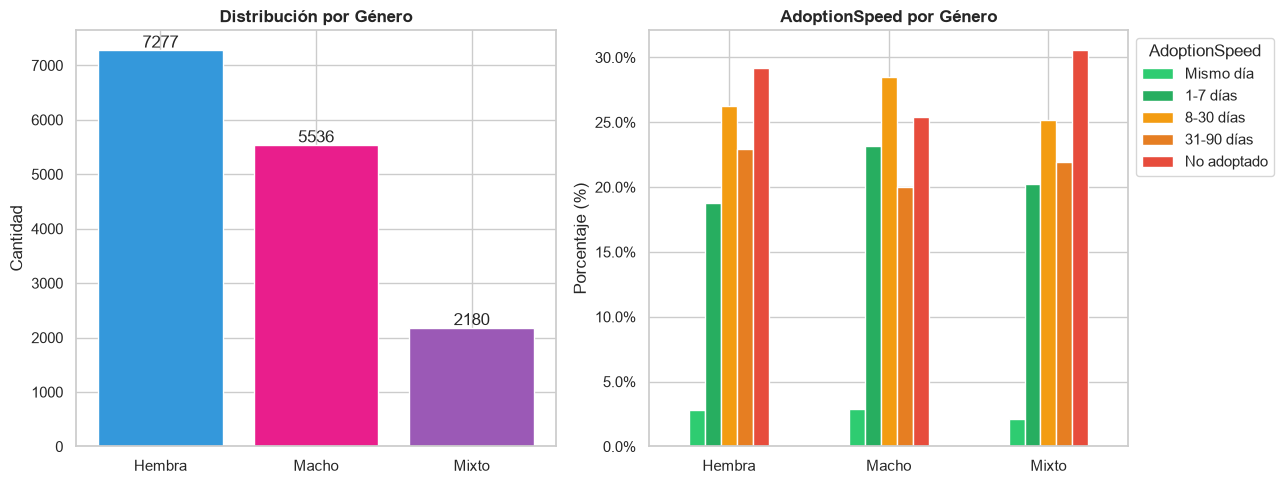

In [32]:
train['Gender_label'] = train['Gender'].map({1:'Macho', 2:'Hembra', 3:'Mixto'})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

gender_counts = train['Gender_label'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values,
            color=['#3498db','#e91e8c','#9b59b6'], edgecolor='white')
axes[0].set_title('Distribución por Género', fontweight='bold')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center')

ct_g = train.groupby(['Gender_label','AdoptionSpeed']).size().unstack()
ct_g_pct = ct_g.div(ct_g.sum(axis=1), axis=0) * 100
ct_g_pct.rename(columns=labels_speed).plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('AdoptionSpeed por Género', fontweight='bold')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='AdoptionSpeed', labels=labels_speed.values(), bbox_to_anchor=(1,1))
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

## 8. 💉 Variables de salud (Vacunado, Desparasitado, Esterilizado)

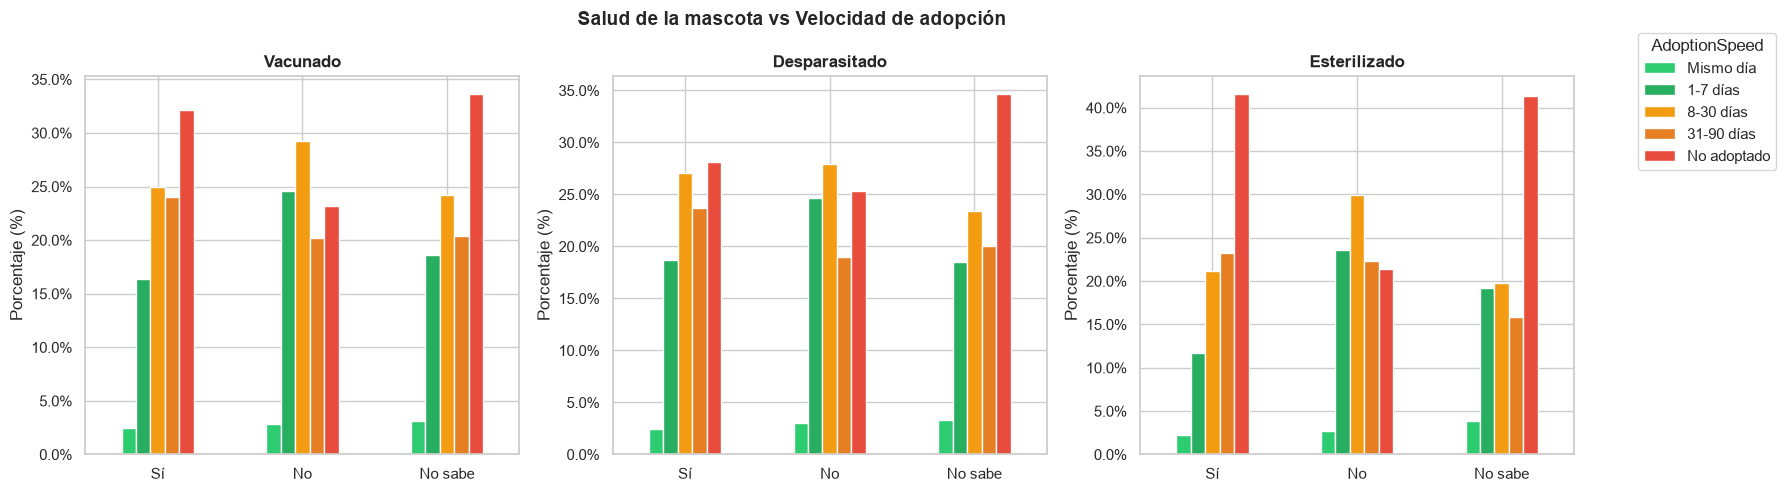

In [33]:
health_map = {1:'Sí', 2:'No', 3:'No sabe'}
health_cols = ['Vaccinated','Dewormed','Sterilized']
health_names = ['Vacunado','Desparasitado','Esterilizado']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, name in zip(axes, health_cols, health_names):
    ct = train.groupby([col,'AdoptionSpeed']).size().unstack().fillna(0)
    ct.index = [health_map[i] for i in ct.index]
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.rename(columns=labels_speed).plot(kind='bar', ax=ax, color=colors, edgecolor='white', legend=False)
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Porcentaje (%)')
    ax.tick_params(axis='x', rotation=0)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Leyenda compartida
handles, _ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_speed.values(), title='AdoptionSpeed',
           loc='upper right', bbox_to_anchor=(1.12, 0.95))

plt.suptitle('Salud de la mascota vs Velocidad de adopción', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. 💰 Tarifa de adopción (Fee)

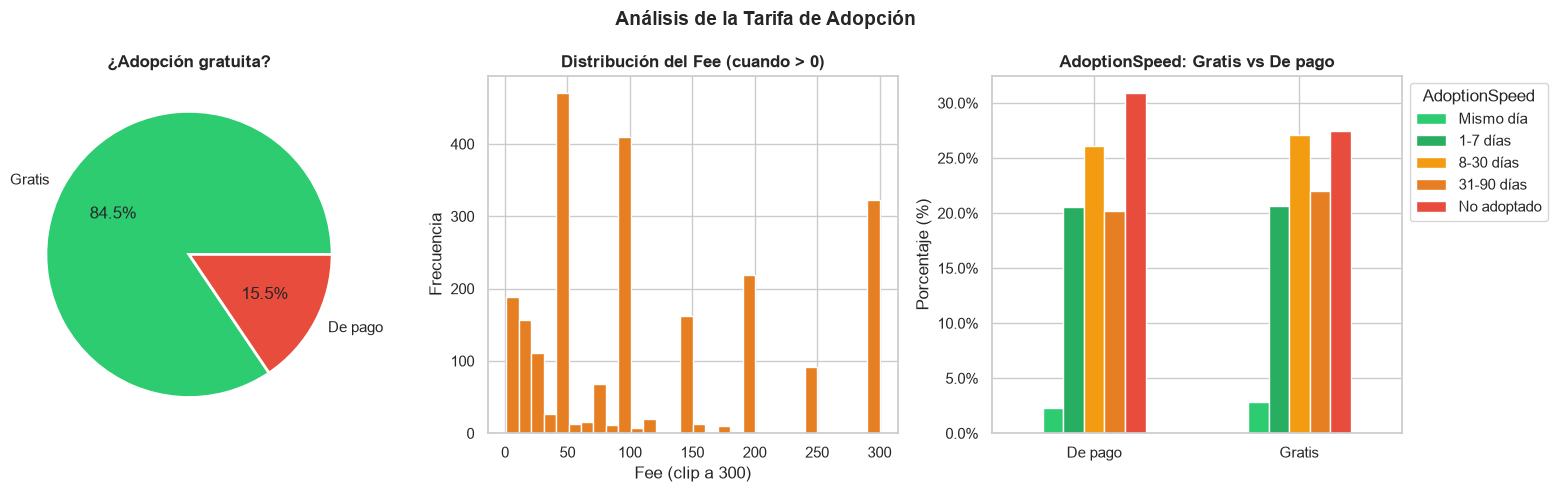

  Mascotas gratis: 12,663 (84.5%)


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ¿Gratis o no?
train['IsFree'] = (train['Fee'] == 0)
free_counts = train['IsFree'].value_counts()
axes[0].pie([free_counts[True], free_counts[False]],
            labels=['Gratis', 'De pago'],
            colors=['#2ecc71','#e74c3c'],
            autopct='%1.1f%%', wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('¿Adopción gratuita?', fontweight='bold')

# Distribución del fee (no gratis)
fee_paid = train[train['Fee'] > 0]['Fee'].clip(upper=300)
axes[1].hist(fee_paid, bins=30, color='#e67e22', edgecolor='white')
axes[1].set_title('Distribución del Fee (cuando > 0)', fontweight='bold')
axes[1].set_xlabel('Fee (clip a 300)')
axes[1].set_ylabel('Frecuencia')

# Fee gratis vs AdoptionSpeed
ct_fee = train.groupby(['IsFree','AdoptionSpeed']).size().unstack().fillna(0)
ct_fee.index = ['De pago','Gratis']
ct_fee_pct = ct_fee.div(ct_fee.sum(axis=1), axis=0) * 100
ct_fee_pct.rename(columns=labels_speed).plot(kind='bar', ax=axes[2], color=colors, edgecolor='white')
axes[2].set_title('AdoptionSpeed: Gratis vs De pago', fontweight='bold')
axes[2].set_ylabel('Porcentaje (%)')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='AdoptionSpeed', labels=labels_speed.values(), bbox_to_anchor=(1,1))
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Análisis de la Tarifa de Adopción', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'  Mascotas gratis: {free_counts[True]:,} ({free_counts[True]/len(train)*100:.1f}%)')

## 10. 📸 Fotos y vídeos

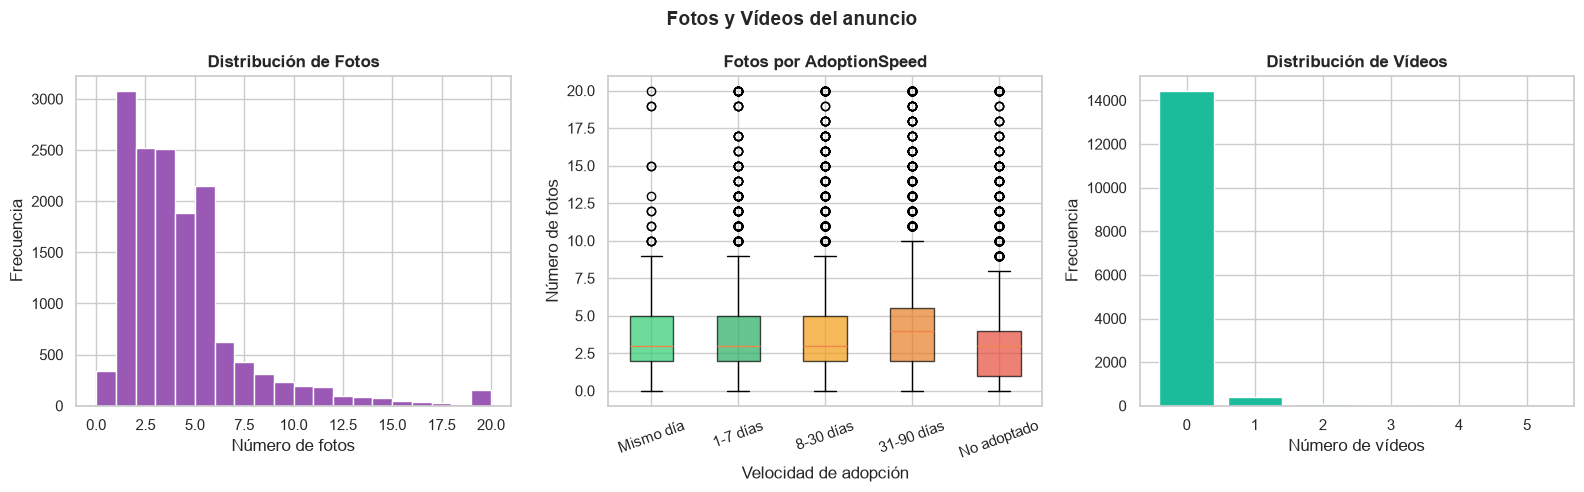

  Sin fotos: 341 mascotas (2.3%)
  Sin vídeos: 14419 mascotas (96.2%)
  Correlación Fotos ↔ AdoptionSpeed: -0.027


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histograma fotos
axes[0].hist(train['PhotoAmt'], bins=20, color='#9b59b6', edgecolor='white')
axes[0].set_title('Distribución de Fotos', fontweight='bold')
axes[0].set_xlabel('Número de fotos')
axes[0].set_ylabel('Frecuencia')

# Boxplot fotos por AdoptionSpeed
data_ph = [train[train['AdoptionSpeed']==i]['PhotoAmt'] for i in range(5)]
bp = axes[1].boxplot(data_ph, tick_labels=[labels_speed[i] for i in range(5)], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Fotos por AdoptionSpeed', fontweight='bold')
axes[1].set_xlabel('Velocidad de adopción')
axes[1].set_ylabel('Número de fotos')
axes[1].tick_params(axis='x', rotation=20)

# Videos
video_counts = train['VideoAmt'].value_counts().sort_index().head(6)
axes[2].bar(video_counts.index.astype(str), video_counts.values, color='#1abc9c', edgecolor='white')
axes[2].set_title('Distribución de Vídeos', fontweight='bold')
axes[2].set_xlabel('Número de vídeos')
axes[2].set_ylabel('Frecuencia')

plt.suptitle('Fotos y Vídeos del anuncio', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'  Sin fotos: {(train["PhotoAmt"]==0).sum()} mascotas ({(train["PhotoAmt"]==0).mean()*100:.1f}%)')
print(f'  Sin vídeos: {(train["VideoAmt"]==0).sum()} mascotas ({(train["VideoAmt"]==0).mean()*100:.1f}%)')

# Correlación fotos-adopción
corr = train['PhotoAmt'].corr(train['AdoptionSpeed'])
print(f'  Correlación Fotos ↔ AdoptionSpeed: {corr:.3f}')

## 11. 📊 Matriz de correlación

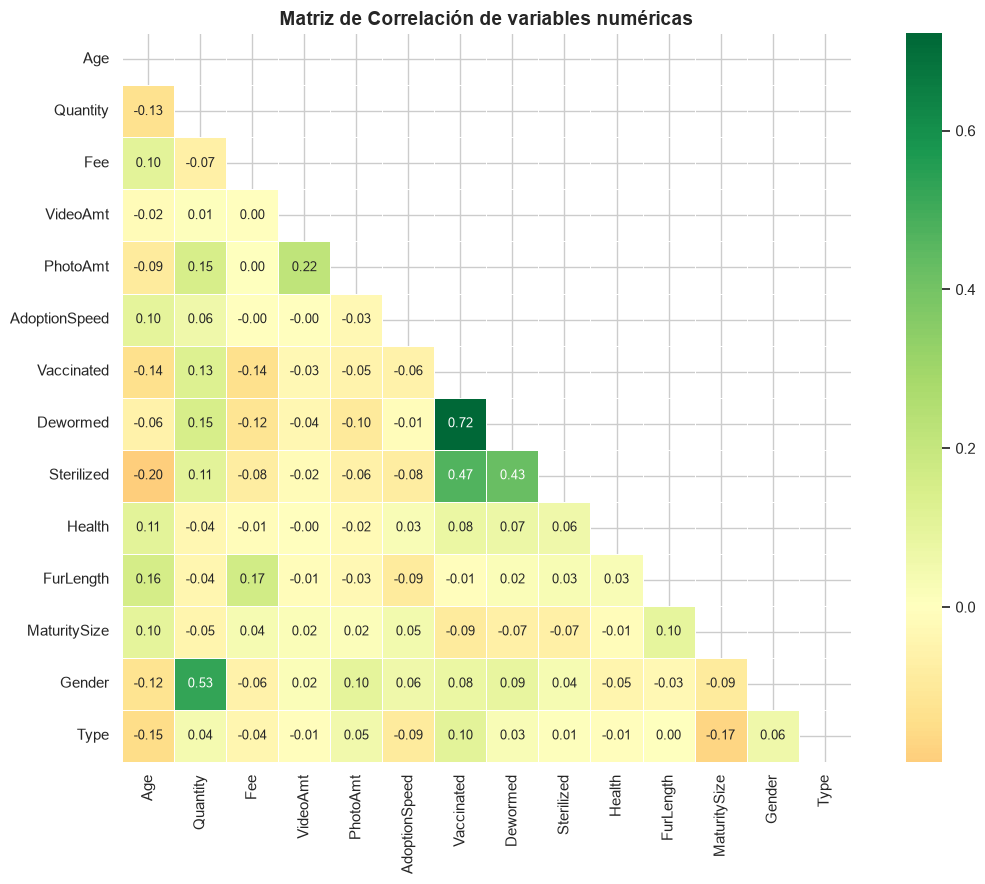


Correlaciones con AdoptionSpeed (ordenadas):
FurLength      -0.091337
Type           -0.091240
Sterilized     -0.083447
Vaccinated     -0.059043
PhotoAmt       -0.026962
Dewormed       -0.013210
Fee            -0.001032
VideoAmt       -0.000571
Health          0.029382
MaturitySize    0.045653
Gender          0.057622
Quantity        0.062802
Age             0.100433


In [36]:
num_cols = ['Age','Quantity','Fee','VideoAmt','PhotoAmt','AdoptionSpeed',
            'Vaccinated','Dewormed','Sterilized','Health','FurLength',
            'MaturitySize','Gender','Type']

corr_matrix = train[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.5, square=True,
            annot_kws={'size':9})
ax.set_title('Matriz de Correlación de variables numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlaciones con AdoptionSpeed
print('\nCorrelaciones con AdoptionSpeed (ordenadas):')
corr_target = corr_matrix['AdoptionSpeed'].drop('AdoptionSpeed').sort_values()
print(corr_target.to_string())

## 12. 📦 Tamaño, pelo y salud

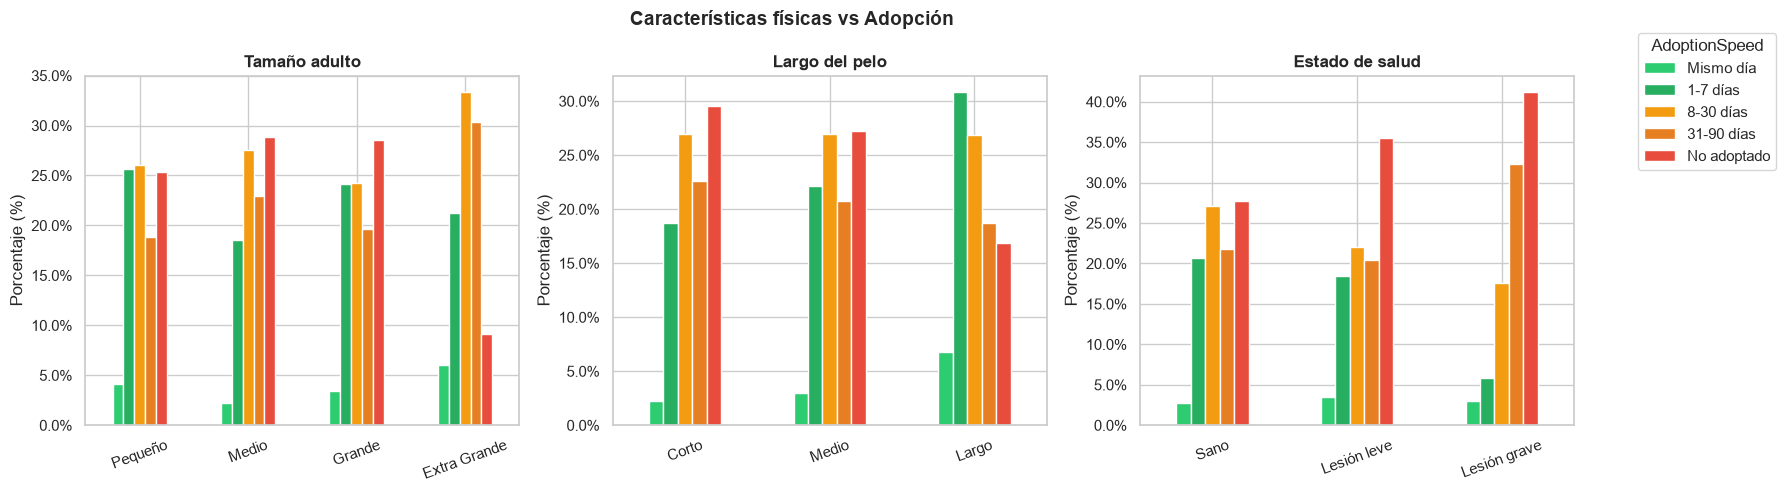

In [37]:
size_map = {1:'Pequeño', 2:'Medio', 3:'Grande', 4:'Extra Grande'}
fur_map  = {1:'Corto', 2:'Medio', 3:'Largo'}
health_map2 = {1:'Sano', 2:'Lesión leve', 3:'Lesión grave'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, name, mapping in zip(
    axes,
    ['MaturitySize','FurLength','Health'],
    ['Tamaño adulto','Largo del pelo','Estado de salud'],
    [size_map, fur_map, health_map2]
):
    ct = train.groupby([col,'AdoptionSpeed']).size().unstack().fillna(0)
    ct.index = [mapping[i] for i in ct.index]
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.rename(columns=labels_speed).plot(kind='bar', ax=ax, color=colors, edgecolor='white', legend=False)
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Porcentaje (%)')
    ax.tick_params(axis='x', rotation=20)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

handles, _ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_speed.values(), title='AdoptionSpeed',
           loc='upper right', bbox_to_anchor=(1.12, 0.95))

plt.suptitle('Características físicas vs Adopción', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. 🔢 Cantidad de mascotas por anuncio

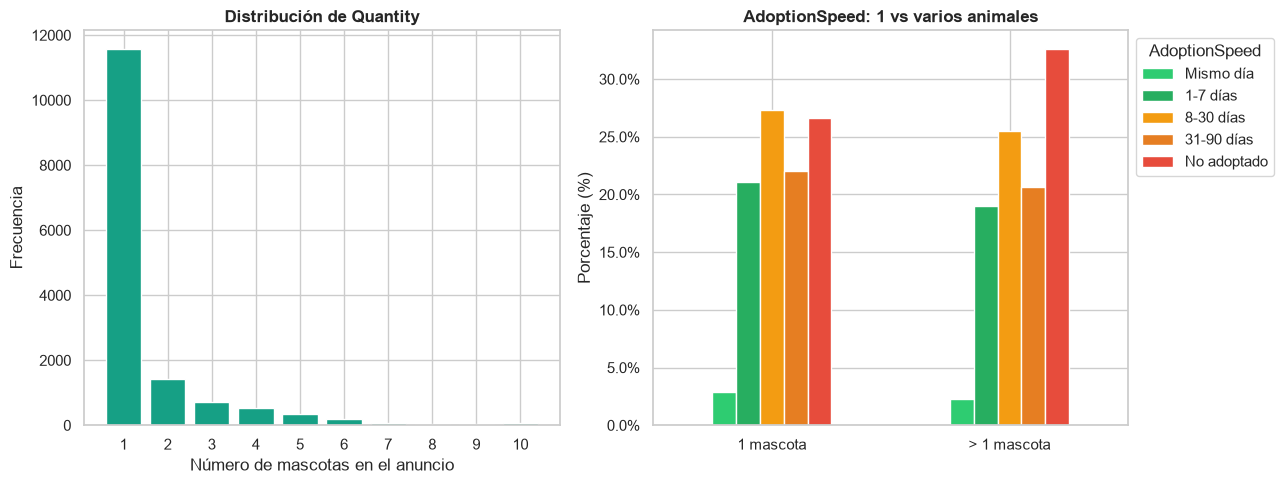

  Anuncios con 1 mascota: 11565 (77.1%)


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

qty = train['Quantity'].value_counts().sort_index().head(10)
axes[0].bar(qty.index.astype(str), qty.values, color='#16a085', edgecolor='white')
axes[0].set_title('Distribución de Quantity', fontweight='bold')
axes[0].set_xlabel('Número de mascotas en el anuncio')
axes[0].set_ylabel('Frecuencia')

# Quantity 1 vs >1
train['MultiPet'] = (train['Quantity'] > 1)
ct_q = train.groupby(['MultiPet','AdoptionSpeed']).size().unstack().fillna(0)
ct_q.index = ['1 mascota', '> 1 mascota']
ct_q_pct = ct_q.div(ct_q.sum(axis=1), axis=0) * 100
ct_q_pct.rename(columns=labels_speed).plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('AdoptionSpeed: 1 vs varios animales', fontweight='bold')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='AdoptionSpeed', labels=labels_speed.values(), bbox_to_anchor=(1,1))
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

print(f'  Anuncios con 1 mascota: {(train["Quantity"]==1).sum()} ({(train["Quantity"]==1).mean()*100:.1f}%)')

## 14. 🏁 Resumen y conclusiones del EDA

In [39]:
print('=' * 65)
print('       CONCLUSIONES DEL EDA - PetFinder Adoption Prediction')
print('=' * 65)

print('''
📌 DATASET
   - 14,993 mascotas en train | 3,948 en test
   - 24 variables originales
   - Valores nulos: solo Name (8.4%) y Description (0.09%) → manejable

🎯 VARIABLE OBJETIVO (AdoptionSpeed)
   - Dataset moderadamente desbalanceado
   - Clases 2, 3 y 4 son dominantes (~80% del total)
   - Clase 0 (mismo día) muy minoritaria (~2.7%)
   → Recomendación: usar class_weight="balanced" o SMOTE

🐾 TIPO DE MASCOTA
   - Más perros (54%) que gatos (46%)
   - Los gatos tienden a tener AdoptionSpeed más alto (más lentos en adoptarse)

📅 EDAD
   - La mayoría son cachorros/gatitos (≤3 meses)
   - Los animales más jóvenes se adoptan más rápido
   - Hay outliers extremos (hasta 255 meses) → tratar en preprocesamiento

💰 TARIFA
   - El 68.7% son gratuitos
   - Las mascotas gratuitas se adoptan algo más rápido

📸 FOTOS
   - Más fotos correlacionan ligeramente con adopciones más rápidas
   - Tener fotos es importante: mascotas sin fotos se adoptan menos

💉 SALUD
   - Mascotas vacunadas y desparasitadas se adoptan más rápido
   - La esterilización tiene un efecto mixto

🔧 PARA EL MODELO (próximos pasos)
   1. Encodear variables categóricas (Type, Gender, etc.)
   2. Tratar outliers en Age y Fee
   3. Crear feature: tiene_nombre, tiene_descripcion, tiene_foto
   4. Usar ensemble (Random Forest, XGBoost) → requerimiento del proyecto
   5. Validación cruzada K-Fold
   6. Ajuste de hiperparámetros con GridSearch/Optuna
''')
print('=' * 65)

       CONCLUSIONES DEL EDA - PetFinder Adoption Prediction

📌 DATASET
   - 14,993 mascotas en train | 3,948 en test
   - 24 variables originales
   - Valores nulos: solo Name (8.4%) y Description (0.09%) → manejable

🎯 VARIABLE OBJETIVO (AdoptionSpeed)
   - Dataset moderadamente desbalanceado
   - Clases 2, 3 y 4 son dominantes (~80% del total)
   - Clase 0 (mismo día) muy minoritaria (~2.7%)
   → Recomendación: usar class_weight="balanced" o SMOTE

🐾 TIPO DE MASCOTA
   - Más perros (54%) que gatos (46%)
   - Los gatos tienden a tener AdoptionSpeed más alto (más lentos en adoptarse)

📅 EDAD
   - La mayoría son cachorros/gatitos (≤3 meses)
   - Los animales más jóvenes se adoptan más rápido
   - Hay outliers extremos (hasta 255 meses) → tratar en preprocesamiento

💰 TARIFA
   - El 68.7% son gratuitos
   - Las mascotas gratuitas se adoptan algo más rápido

📸 FOTOS
   - Más fotos correlacionan ligeramente con adopciones más rápidas
   - Tener fotos es importante: mascotas sin fotos se ad